In [34]:
import torch
import torch.nn as nn
from timm import create_model
from torchvision import transforms
from PIL import Image
import numpy as np
import cv2
import os
from captum.attr import IntegratedGradients, Occlusion, LayerGradCam, LayerAttribution
from transformers import SwinForImageClassification
from torchvision.models.swin_transformer import swin_t
import torchvision.models as tv_models  # pra pegar Swin_T_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [35]:
# === recria o MESMO modelo do treino ===
swin = swin_t(weights=None)  # atenção: agora o nome da variável é swin

# head com 2 classes, igual ao get_swin_model()
num_features = swin.head.in_features
swin.head = nn.Linear(num_features, 2)

# === carrega o checkpoint treinado ===
path_swin = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\4-redes\3.swin\swin-sem-optuna\modelos_salvos_swin\swin_fold2.pth"
state = torch.load(path_swin, map_location=device)

# como você salvou: torch.save(model.state_dict(), ...)
swin.load_state_dict(state)

swin.to(device)
swin.eval()


C:\Users\sthem\AppData\Local\Temp\ipykernel_39980\1291027140.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path_swin, map_location=device)


SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=384, out_features=96, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock(
       

In [36]:
normalize_imagenet = transforms.Normalize(
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225)
)

transform_gray = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    normalize_imagenet,
])

def load_image(path, mode="gray"):
    img = Image.open(path)
    if mode == "gray":
        x = transform_gray(img)
    else:
        x = transform_rgb(img)  # se quiser usar NIH também
    return img, x.unsqueeze(0).to(device)

def save_overlay(pil_img, heatmap, out_path, alpha=0.5):
    img = np.array(pil_img.resize((heatmap.shape[-1], heatmap.shape[-2])))
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    hm = heatmap.squeeze().numpy()
    hm = (hm * 255).astype(np.uint8)
    hm_color = cv2.applyColorMap(hm, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img, 1 - alpha, hm_color, alpha, 0)
    cv2.imwrite(out_path, overlay)



In [45]:
def explain_ig(model, x, target=None, n_steps=50, baseline=None):
    model.zero_grad()
    model.eval()

    # classe alvo
    if target is None:
        with torch.no_grad():
            target = model(x).argmax(dim=1).item()

    # se não passar baseline, usa preto por padrão
    if baseline is None:
        baseline = torch.zeros_like(x)

    ig = IntegratedGradients(model)
    attributions, _ = ig.attribute(
        x,
        baselines=baseline,
        target=target,
        n_steps=n_steps,
        return_convergence_delta=True
    )

    # agrega canais e normaliza para [0,1]
    attr = attributions.abs().sum(dim=1, keepdim=True)
    attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)
    return attr.detach().cpu(), target


In [38]:
def explain_occlusion(model, x, target=None, window=15, stride=8, baseline=0):
    model.zero_grad()
    model.eval()

    if target is None:
        with torch.no_grad():
            target = model(x).argmax(dim=1).item()

    occ = Occlusion(model)
    attributions = occ.attribute(
        x,
        strides=(3, stride, stride),
        sliding_window_shapes=(3, window, window),
        baselines=baseline,
        target=target
    )

    attr = attributions.mean(dim=1, keepdim=True)
    attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)
    return attr.detach().cpu(), target


## GradCAM Swin

In [39]:
for name, module in swin.named_modules():
    print(name)



features
features.0
features.0.0
features.0.1
features.0.2
features.1
features.1.0
features.1.0.norm1
features.1.0.attn
features.1.0.attn.qkv
features.1.0.attn.proj
features.1.0.stochastic_depth
features.1.0.norm2
features.1.0.mlp
features.1.0.mlp.0
features.1.0.mlp.1
features.1.0.mlp.2
features.1.0.mlp.3
features.1.0.mlp.4
features.1.1
features.1.1.norm1
features.1.1.attn
features.1.1.attn.qkv
features.1.1.attn.proj
features.1.1.stochastic_depth
features.1.1.norm2
features.1.1.mlp
features.1.1.mlp.0
features.1.1.mlp.1
features.1.1.mlp.2
features.1.1.mlp.3
features.1.1.mlp.4
features.2
features.2.reduction
features.2.norm
features.3
features.3.0
features.3.0.norm1
features.3.0.attn
features.3.0.attn.qkv
features.3.0.attn.proj
features.3.0.stochastic_depth
features.3.0.norm2
features.3.0.mlp
features.3.0.mlp.0
features.3.0.mlp.1
features.3.0.mlp.2
features.3.0.mlp.3
features.3.0.mlp.4
features.3.1
features.3.1.norm1
features.3.1.attn
features.3.1.attn.qkv
features.3.1.attn.proj
feature

In [40]:
def inspect_layer_output(layer, model, x):
    def hook(module, inp, out):
        print(f"Tipo da saída: {type(out)}")
        try:
            print("Shape da saída:", out.shape)
        except AttributeError:
            print("Saída não tem atributo .shape:", out)

    h = layer.register_forward_hook(hook)
    with torch.no_grad():
        _ = model(x)
    h.remove()


In [41]:
swin_layer = swin.features[3][-1].norm2   # último stage, último bloco
swin_layer

LayerNorm((192,), eps=1e-05, elementwise_affine=True)

In [42]:
def explain_gradcam_swin(x, target=None):
    swin.zero_grad()
    swin.eval()

    if target is None:
        with torch.no_grad():
            target = swin(x).argmax(dim=1).item()

    gradcam = LayerGradCam(swin, swin_layer)
    attributions = gradcam.attribute(x, target=target)

    upsampled = LayerAttribution.interpolate(attributions, x.shape[2:])
    attr = (upsampled - upsampled.min()) / (upsampled.max() - upsampled.min() + 1e-8)
    return attr.detach().cpu(), target


In [46]:
img_path = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_annot_jpg\train\infected\2022_03_21_11_02_58_05_cell0012.png"
pil_img, x = load_image(img_path, mode="gray")

with torch.no_grad():
    logits = swin(x)
    pred = logits.argmax(1).item()
print("Predição Swin:", pred)

# b1 = imagem preta
baseline_b1 = torch.zeros_like(x)
ig_b1, _ = explain_ig(swin, x, target=pred, baseline=baseline_b1)

# b2 = imagem "lavada" (mesmo que preta no seu caso, mas deixei separado)
baseline_b2 = x * 0
ig_b2, _ = explain_ig(swin, x, target=pred, baseline=baseline_b2)

# b3 = imagem cinza
baseline_b3 = torch.ones_like(x) * 0.5
ig_b3, _ = explain_ig(swin, x, target=pred, baseline=baseline_b3)

occ_map, _ = explain_occlusion(swin, x, target=pred)
gc_map, _  = explain_gradcam_swin(x, target=pred)

os.makedirs("xai_swin_test", exist_ok=True)
save_overlay(pil_img, ig_b1, "xai_swin_test/ig_overlay_b1.png")
save_overlay(pil_img, ig_b2, "xai_swin_test/ig_overlay_b2.png")
save_overlay(pil_img, ig_b3, "xai_swin_test/ig_overlay_b3.png")
save_overlay(pil_img, occ_map, "xai_swin_test/occ_overlay.png")
save_overlay(pil_img, gc_map,  "xai_swin_test/gc_overlay.png")

Predição Swin: 0


## Testando alguns pontos do IG

In [44]:
print(ig_map.shape, ig_map.min().item(), ig_map.max().item(), ig_map.mean().item())


torch.Size([1, 1, 224, 224]) 0.0 1.0 0.05063402280211449


In [47]:
import torch.nn.functional as F

def cosine_sim(a, b):
    return F.cosine_similarity(a.flatten(), b.flatten(), dim=0).item()

print("b1 x b2:", cosine_sim(ig_b1, ig_b2))
print("b1 x b3:", cosine_sim(ig_b1, ig_b3))


b1 x b2: 0.9999995231628418
b1 x b3: 0.626969039440155


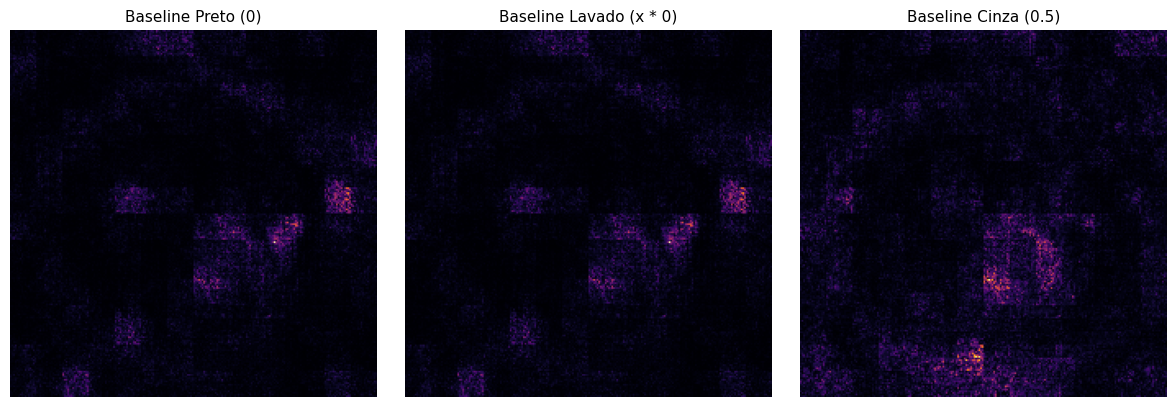

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Converter para numpy e remover dimensões extras
ig_b1_np = ig_b1.squeeze().numpy()
ig_b2_np = ig_b2.squeeze().numpy()
ig_b3_np = ig_b3.squeeze().numpy()

# Configurar a figura
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Mostrar cada mapa
titles = ['Baseline Preto (0)', 'Baseline Lavado (x * 0)', 'Baseline Cinza (0.5)']
imgs = [ig_b1_np, ig_b2_np, ig_b3_np]

for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img, cmap='inferno')  # você pode usar 'hot', 'plasma', 'jet', etc.
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()


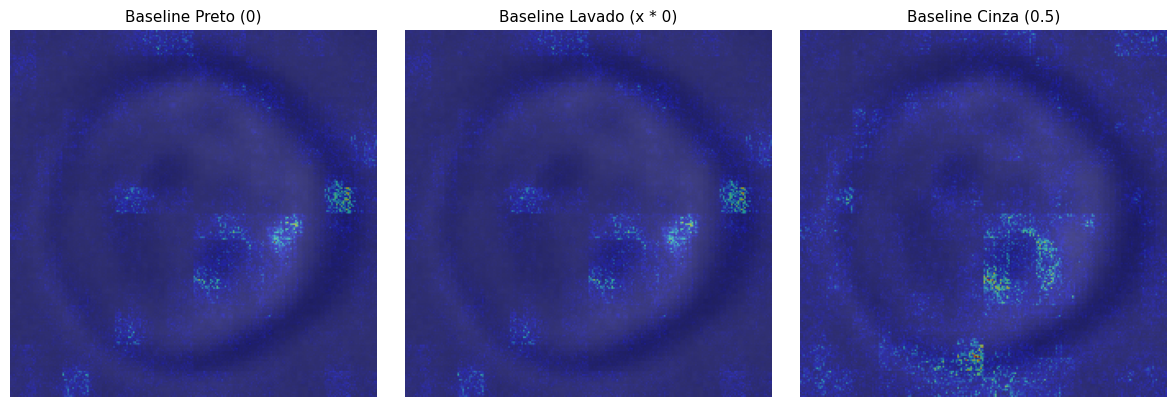

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
orig = np.array(pil_img.resize((224, 224)))

for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(orig)
    ax.imshow(img, cmap='jet', alpha=0.5)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()


In [50]:
fig.savefig("xai_swin_test/IG_comparativo_baselines.png", dpi=300, bbox_inches='tight')
